## <center> <span style="color: red;">Rapport du projet de Monte-carlo( Partie Code) <span></center>

## <center> <u> Simulation de la Ruine du casino </u>  </center>
***Cette partie a pour objectif d’illustrer par la méthode de Monte-Carlo les résultats théoriques obtenus sur la probabilité de ruine du casino.
Les simulations numériques permettent d’observer empiriquement les différents régimes du modèle selon la valeur du paramètre α par rapport à μ, ainsi que d’évaluer la robustesse des résultats face au choix de la loi des gains.***


## 1-**Simulation du processus et modélisation de r(y)**
### 1.1 Rappel du modèle théorique

### 1.2 Simulation du processus en fonction de trois lois différentes:**loi exponentielle**, **loi uniforme**, et **loi gamma**
**Objectif** 
<div> Comparer empiriquement la probabilité de ruine lorsque la loi des gains suit différentes distributions, tout en conservant la même espérance μ.</div>  

**Methode** 
<div>Pour chaque loi, on simule un grand nombre de trajectoires indépendantes du processus jusqu’à un horizon temporel fixé, et on estime la proportion de trajectoires menant à la ruine.</div>  




### Démonstration dans le cas où **$\alpha$ >$\mu$**
Pour avoir les autres cas on pourra faire varier les valeurs de $\alpha$  et $\mu$ 

Loi exponentielle : 47.09 % de ruine
Loi uniforme : 38.84 % de ruine
Loi gamma : 41.46 % de ruine


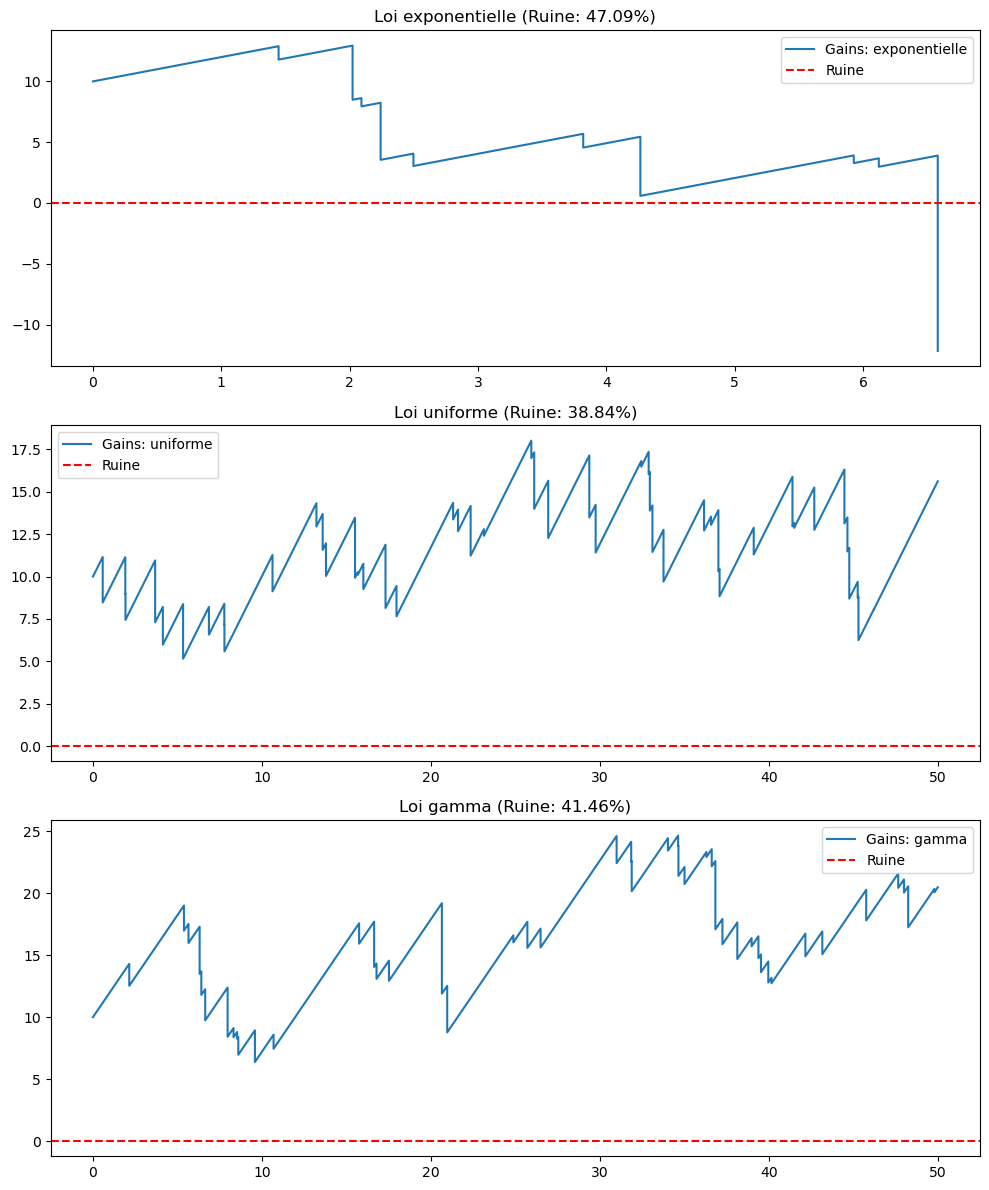

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# paramètres pour simulation processus
y_initial = 10
alpha = 2
mu_gains = 1.9
T_max = 50
nb_simulations = 10000 # Nombre de simulations pour le calcul du %

# On définit les 3 types de lois à tester
types_de_lois = ["exponentielle", "uniforme", "gamma"]

#  Simulation et Graphiques 
plt.figure(figsize=(10, 12))

for i, loi in enumerate(types_de_lois):
    cas_de_ruine = 0
    
    # --- PARTIE A : Calcul du pourcentage de ruine ---
    for sim in range(nb_simulations):
        t_sim = 0
        y_sim = y_initial
        while t_sim < T_max:
            duree = np.random.exponential(1.0)
            t_sim = t_sim + duree
            if t_sim > T_max: break
            
            # Tirage du gain selon la loi choisie
            if loi == "exponentielle":
                gain = np.random.exponential(mu_gains)
            elif loi == "uniforme":
                gain = np.random.uniform(0, 2 * mu_gains) # Moyenne = mu
            else: # loi Gamma (pour représenter une loi "quelconque")
                gain = np.random.gamma(2, mu_gains / 2)   # Moyenne = mu
            
            y_sim = y_sim + (alpha * duree) - gain
            if y_sim < 0:
                cas_de_ruine = cas_de_ruine + 1
                break
    
    pourcentage = (cas_de_ruine / nb_simulations) * 100
    print(f"Loi {loi} : {pourcentage:.2f} % de ruine")

    # --- PARTIE B : Création d'un graphique pour cette loi ---
    temps_plot = [0]
    capital_plot = [y_initial]
    t_graph = 0
    y_graph = y_initial
    
    while t_graph < T_max:
        duree = np.random.exponential(1.0)
        t_saut = t_graph + duree
        
        if t_saut > T_max:
            temps_plot.append(T_max)
            capital_plot.append(y_graph + alpha * (T_max - t_graph))
            break
        
        # Point HAUT (juste avant que le joueur gagne)
        y_avant = y_graph + (alpha * duree)
        temps_plot.append(t_saut)
        capital_plot.append(y_avant)
        
        # Tirage du gain pour le graphique
        if loi == "exponentielle": gain = np.random.exponential(mu_gains)
        elif loi == "uniforme": gain = np.random.uniform(0, 2 * mu_gains)
        else: gain = np.random.gamma(2, mu_gains / 2)
        
        # Point BAS (juste après le gain du joueur)
        y_graph = y_avant - gain
        t_graph = t_saut
        temps_plot.append(t_graph)
        capital_plot.append(y_graph)
        
        if y_graph < 0: break

    # Dessin du sous-graphique
    plt.subplot(3, 1, i+1)
    plt.plot(temps_plot, capital_plot, label=f"Gains: {loi}")
    plt.axhline(0, color='red', linestyle='--',label=f"Ruine")
    plt.title(f"Loi {loi} (Ruine: {pourcentage:.2f}%)")
    plt.legend()

plt.tight_layout()
plt.show()


# 2-Choix du paramètre $\alpha$ des rentrées d'argent: étude des trois régimes  
###  Cas critique $\alpha$=$\mu$ 
*Dans le cas critique α = μ, l’espérance des incréments est nulle. Le processus n’a pas de dérive et se comporte comme une marche aléatoire centrée.
Le théorème central limite joue alors un rôle clé dans l’étude asymptotique du capital.*
### Illustration du TCL $\frac{S_n}{\sqrt{n}}$
*On simule un grand nombre de trajectoires et on étudie la convergence en loi de $\frac{S_n}{\sqrt{n}}$ vers une loi normale, conformément au théorème central limite.*


SIMULATION : CASINO EN CAS CRITIQUE (α = μ)


C:\Users\gbada\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gbada\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


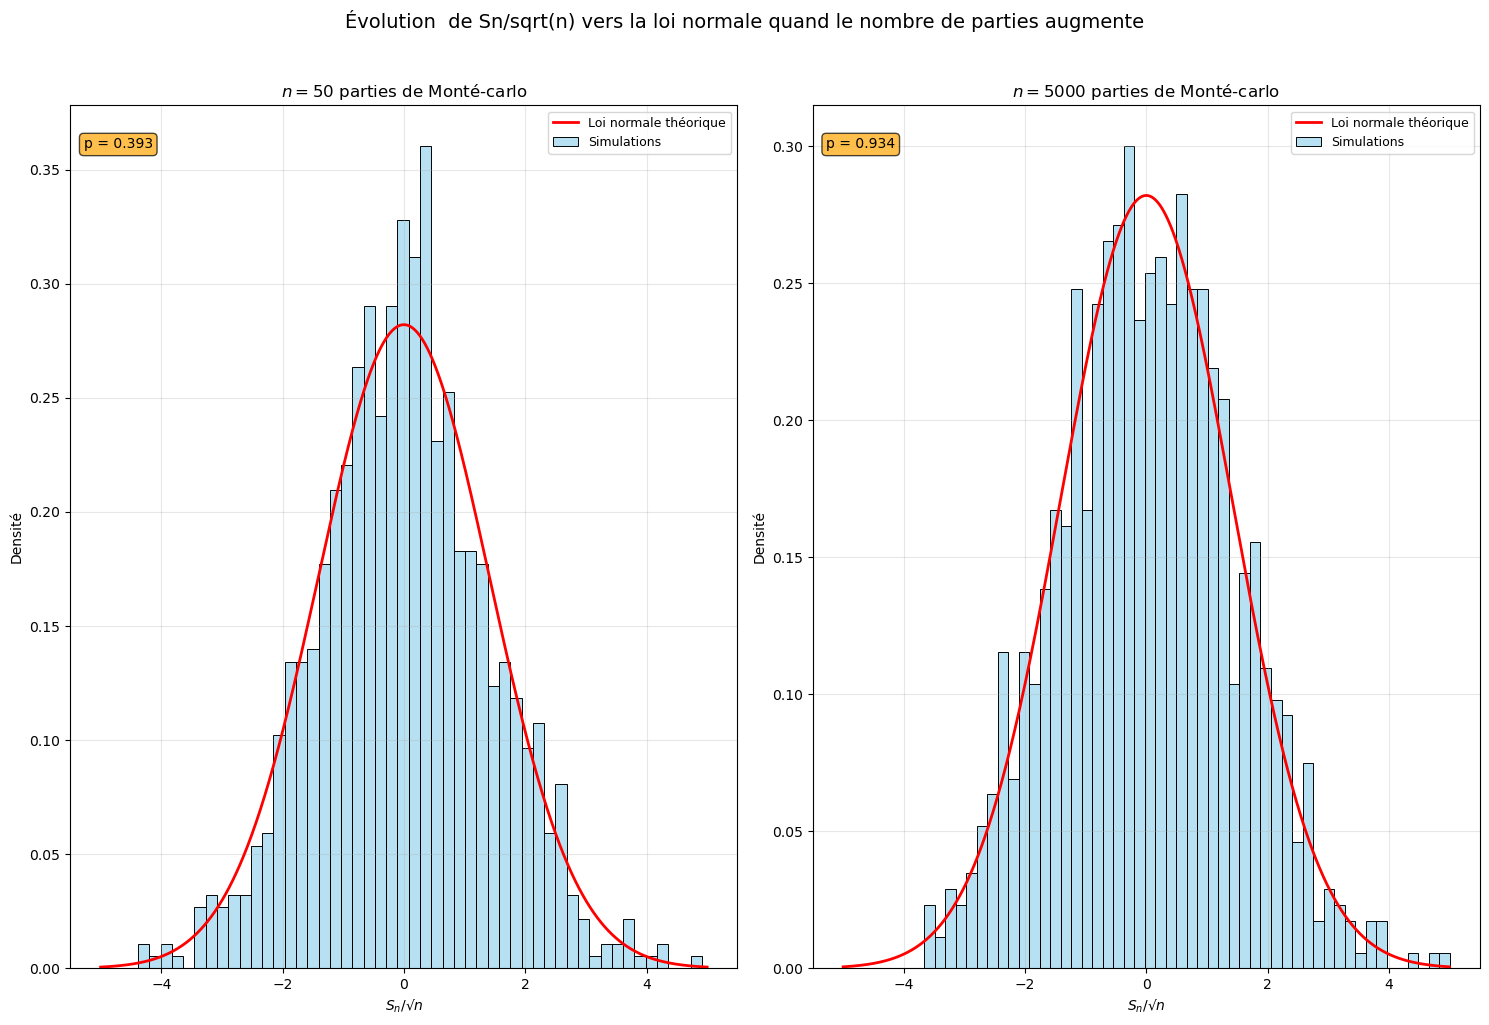

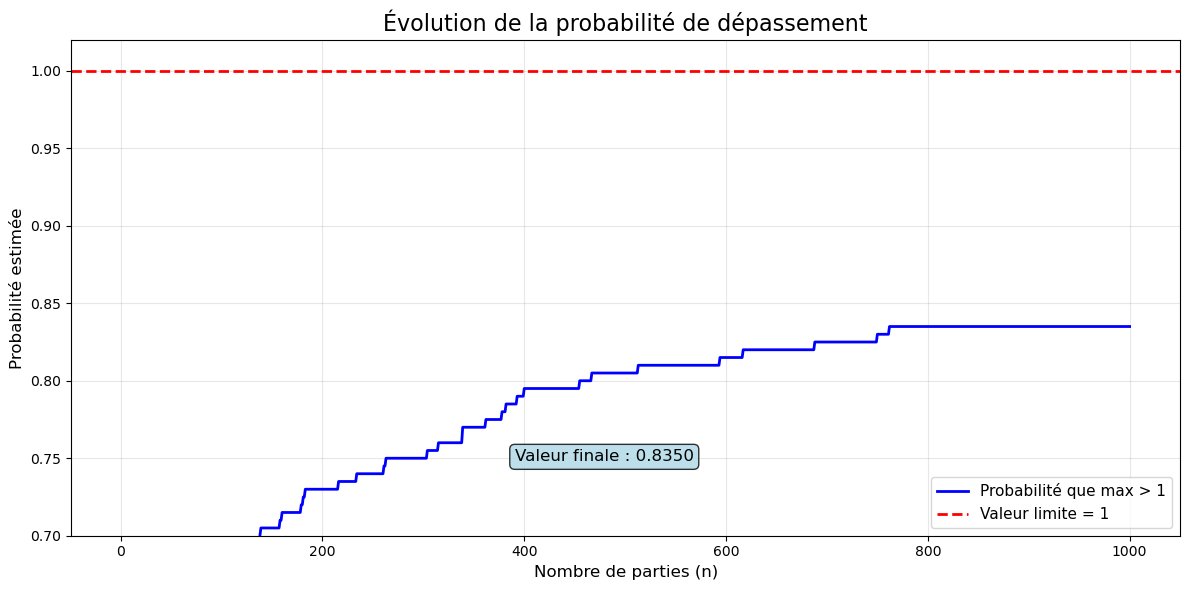

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Initialisation pour des résultats reproductibles
np.random.seed(42)

print("SIMULATION : CASINO EN CAS CRITIQUE (α = μ)")



# Gain moyen d'un joueur
gain_moyen_joueur = 1  # μ = E[X_i]

# Tarif du casino (par unité de temps)
alpha1 = gain_moyen_joueur  # α = μ (cas critique)



#Plus on observe de parties (n grand), plus l'histogramme ressemble à la courbe rouge.


def graphique_simple_convergence():
    
    # Différents nombres d'observations à comparer
    tailles_echantillons = [50,5000]
    nombre_simulations = 1000
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    # Calcul théorique
    variance_theorique = 2 * gain_moyen_joueur**2
    
    for i, n in enumerate(tailles_echantillons):
        # SIMULATION
        # 1. Gains des joueurs (aléatoires)
        gains_joueurs = np.random.exponential(scale=gain_moyen_joueur, 
                                            size=(nombre_simulations, n))
        # 2. Temps entre arrivées (aléatoires)
        temps_entre_arrivees = np.random.exponential(scale=1, 
                                                   size=(nombre_simulations, n))
        # 3. Différence entre gains et tarifs
        differences = gains_joueurs - alpha1  * temps_entre_arrivees
        # 4. Somme cumulée
        somme_cumulee = np.sum(differences, axis=1)
        # 5. Normalisation (diviser par racine de n)
        valeur_normalisee = somme_cumulee / np.sqrt(n)
        
        # TEST STATISTIQUE
        stat, p_value = stats.kstest(valeur_normalisee, 'norm', 
                                 args=(0, np.sqrt(variance_theorique)))
        
        # GRAPHIQUE
        ax = axes[i]
        
        # Histogramme des simulations (bleu)
        sns.histplot(valeur_normalisee, bins=50, stat='density', alpha=0.6, 
                    ax=ax, color='skyblue', label='Simulations')
        
        # Courbe théorique normale (rouge)
        x = np.linspace(-5, 5, 1000)
        courbe_normale = stats.norm.pdf(x, 0, np.sqrt(variance_theorique))
        ax.plot(x, courbe_normale, 'r-', lw=2, label='Loi normale théorique')
        
        # Ajout de la p-value (test de qualité d'ajustement)
        ax.text(0.02, 0.95, f'p = {p_value:.3f}', 
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))
        
        # Mise en forme
        ax.set_title(f'$n = {n}$ parties de Monté-carlo')
        ax.set_xlabel('$S_n/√n$')
        ax.set_ylabel('Densité')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("Évolution  de Sn/sqrt(n) vers la loi normale quand le nombre de parties augmente", 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Affichage du graphique
graphique_simple_convergence()



def graphique_simple_loi_01():
  
    
    # Paramètres de simulation
    nombre_parties_max = 1000  # Nombre maximum de parties à simuler, plus nmax est grnd plus on tend vers 1
    nombre_casinos = 200     # Nombre de casinos simulés en parallèle
    
    # SIMULATION
    # 1. Génération des données
    gains = np.random.exponential(scale=gain_moyen_joueur, 
                                size=(nombre_casinos, nombre_parties_max))
    temps = np.random.exponential(scale=1.0, 
                                size=(nombre_casinos, nombre_parties_max))
    
    # 2. Calcul des différences
    differences = gains - alpha1* temps
    
    # 3. Somme cumulée au fil du temps
    fortune_cumulee = np.cumsum(differences, axis=1)
    
    # 4. Normalisation
    indices = np.arange(1, nombre_parties_max + 1)
    racine_n = np.sqrt(indices)
    fortune_normalisee = fortune_cumulee / racine_n.reshape(1, -1)
    
    # 5. Calcul de la probabilité au fil du temps
    probabilites = np.zeros(nombre_parties_max)
    for i in range(nombre_parties_max):
        # Pour chaque instant i, on regarde combien de casinos ont dépassé 1
        casinos_ruines = np.max(fortune_normalisee[:, :i+1], axis=1) > 1.0
        probabilites[i] = np.mean(casinos_ruines)
    
    # 6. Résultat final
    probabilite_finale = probabilites[-1]
    
    # GRAPHIQUE SIMPLE
    plt.figure(figsize=(12, 6))
    
    # Courbe d'évolution
    plt.plot(indices, probabilites, 'b-', linewidth=2, 
            label='Probabilité que max > 1')
    
    # Ligne horizontale à 1
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
               label='Valeur limite = 1')
    
    
    # Mise en forme
    plt.title("Évolution de la probabilité de dépassement", fontsize=16)
    plt.xlabel("Nombre de parties (n)", fontsize=12)
    plt.ylabel("Probabilité estimée", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(0.7, 1.02)
    plt.legend(loc='lower right', fontsize=11)
    
    # Annotation du résultat final
    plt.text(0.4, 0.15, 
            f'Valeur finale : {probabilite_finale:.4f}',
            transform=plt.gca().transAxes, fontsize=12,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    
    plt.tight_layout()
    plt.show()
    
   

# Affichage du graphique
graphique_simple_loi_01()



###  Cas défavorable $\alpha$<$\mu$ 
*Lorsque α < μ, la dérive moyenne du processus est négative. Le capital décroît en moyenne, et la ruine est alors certaine.
Les simulations confirment que la probabilité de ruine tend vers 1, indépendamment du capital initial.*

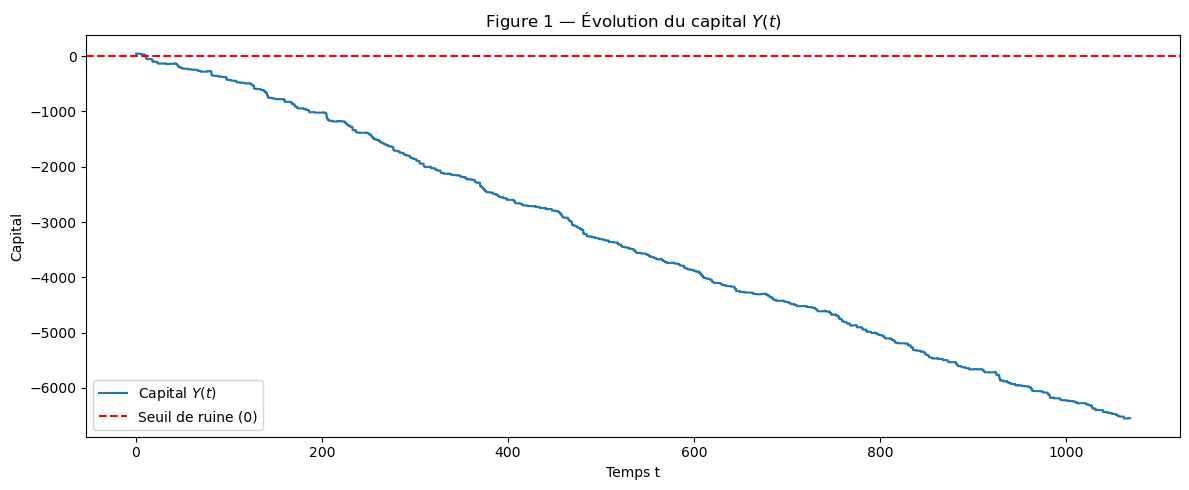

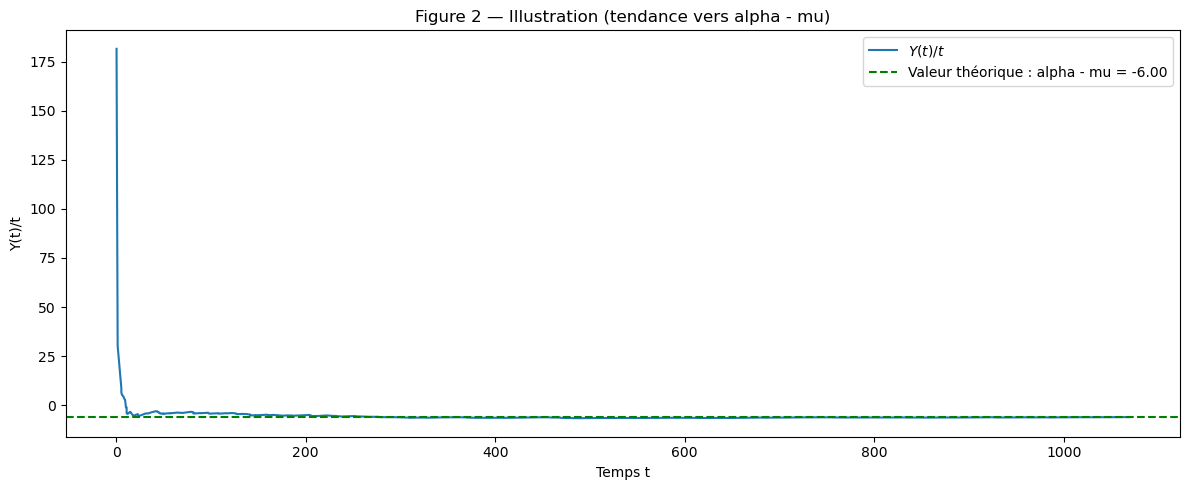

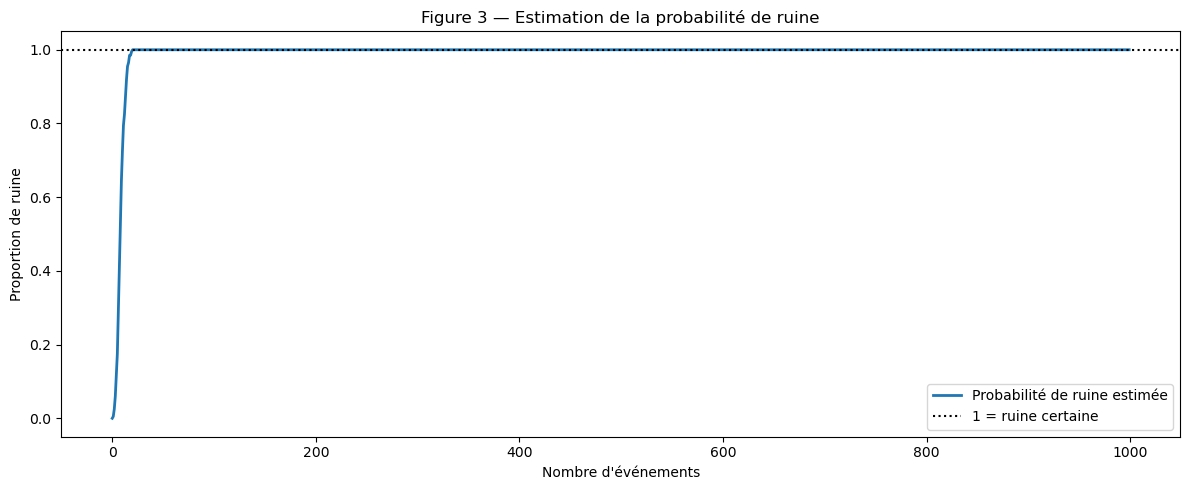

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Paramètres du modèle
y0 = 50.0        # Capital initial du casino
alpha = 2        # Gain du casino par unité de temps (ex: gains réguliers)
mu = 8           # Moyenne des pertes (mise gagnée par les joueurs)
n_pas = 1000   # Nombre d'événements (nombre de clients / parties)
n_sim = 200      # Nombre de simulations pour estimer la probabilité de ruine

# Temps entre deux événements ~ Exponentielle(1)
xi = np.random.exponential(scale=1.0, size=n_pas)

# T = temps cumulé (T[f0] = 1er temps, T[1] = 1er+2e, etc.)
T = np.cumsum(xi)

# Pertes à chaque événement ~ Exponentielle(mu)
X = np.random.exponential(scale=mu, size=n_pas)

# Somme cumulée des pertes
sum_X = np.cumsum(X)

# Capital du casino au temps T :
# capital = capital initial + gains réguliers - pertes cumulées
Y = y0 + alpha * T - sum_X

# Rapport Y(t)/t (utile pour observer une convergence vers alpha - mu)
Y_divise_t = Y / T


#Capital Y(t)
plt.figure(figsize=(12, 5))
plt.step(T, Y, where="post", label="Capital $Y(t)$")
plt.axhline(0, color="red", linestyle="--", label="Seuil de ruine (0)")
plt.title("Figure 1 — Évolution du capital $Y(t)$")
plt.xlabel("Temps t")
plt.ylabel("Capital")
plt.legend()
plt.tight_layout()
plt.show()


# FIGURE 2 : Rapport Y(t)/t
plt.figure(figsize=(12, 5))
plt.plot(T, Y_divise_t, label=r"$Y(t)/t$")
plt.axhline(alpha - mu, color="green", linestyle="--",
            label=f"Valeur théorique : alpha - mu = {alpha - mu:.2f}")
plt.title("Figure 2 — Illustration (tendance vers alpha - mu)")
plt.xlabel("Temps t")
plt.ylabel("Y(t)/t")
plt.legend()
plt.tight_layout()
plt.show()


# 3) Estimer r(y) : probabilité de ruine au fil des événements
# Principe de montécarlo appliqué :
# - On refait n_sim fois une trajectoire du casino
# - À chaque étape, on regarde si le casino est déjà passé sous 0
# - On compte combien de simulations sont ruinées à chaque étape
ruine_compte = np.zeros(n_pas)

for j in range(n_sim):
    # On simule une nouvelle trajectoire
    xi_sim = np.random.exponential(scale=1.0, size=n_pas)
    T_sim = np.cumsum(xi_sim)

    X_sim = np.random.exponential(scale=mu, size=n_pas)
    Y_sim = y0 + alpha * T_sim - np.cumsum(X_sim)

    # minimum.accumulate(Y_sim) = le minimum atteint jusqu’à chaque étape
    # si ce minimum est < 0, alors la ruine est arrivée (à cette étape ou avant)
    ruine = np.minimum.accumulate(Y_sim) < 0

    # On ajoute 1 à chaque étape où la simulation est ruinée
    ruine_compte += ruine

# Proportion de simulations ruinées à chaque étape = estimation de r(y)
r_estime = ruine_compte / n_sim



# FIGURE 3 : Probabilité de ruine estimée
plt.figure(figsize=(12, 5))
plt.plot(range(n_pas), r_estime, linewidth=2, label="Probabilité de ruine estimée")
plt.axhline(1.0, color="black", linestyle=":", label="1 = ruine certaine")
plt.title("Figure 3 — Estimation de la probabilité de ruine")
plt.xlabel("Nombre d'événements")
plt.ylabel("Proportion de ruine")
plt.legend()
plt.tight_layout()
plt.show()


# 3- Test d'adéquation et validation du modèle exponentiel
### Simulations liées au test basé sur la statistique $Hn$
*La statistique Hn mesure l’écart maximal entre la fonction de répartition empirique et la loi exponentielle ajustée.*

=== PARAMÈTRES ===
n = 500
moyenne mu = 1.004
alpha = 1.2
condition alpha > mu : True

=== TEST EXPONENTIEL ===
Hn observé = 0.0426
Seuil 95% = 0.0479
Conclusion : OK (compatible exponentielle)

=== PROBA DE RUINE ===
y= 0  MC=1.0000  Théorie=0.8369
y= 5  MC=0.3400  Théorie=0.3716
y=10  MC=0.1400  Théorie=0.1650
y=15  MC=0.0450  Théorie=0.0733
y=20  MC=0.0250  Théorie=0.0325
y=25  MC=0.0100  Théorie=0.0144
y=30  MC=0.0050  Théorie=0.0064
y=35  MC=0.0000  Théorie=0.0028
y=40  MC=0.0000  Théorie=0.0013


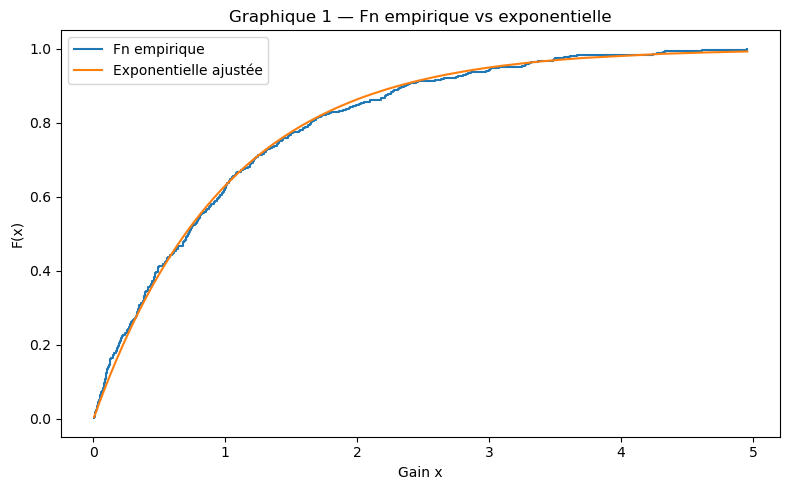

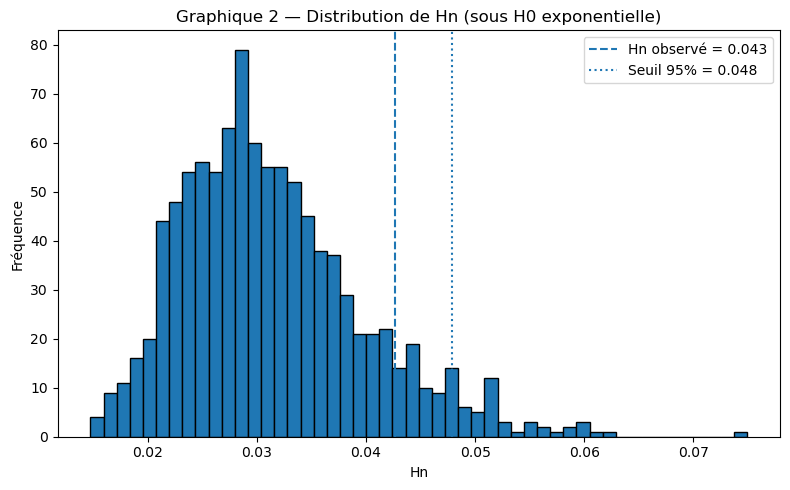

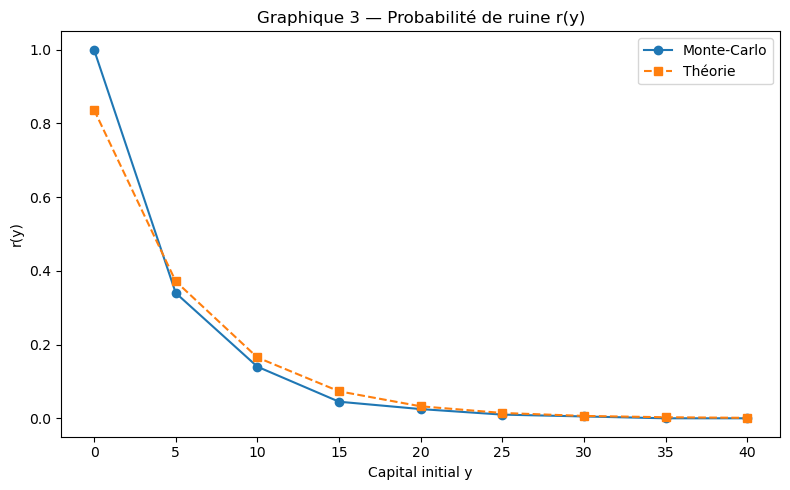


=== CONCLUSION ===
gamma ≈ 0.996
r(y) théorique = exp(-(gamma - 1/alpha)*y) / (alpha*gamma)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt



np.random.seed(42) #pour avoir les memes probabilite pour la ruine quand on run plusierus fois le code 

n = 500                      # taille de l'échantillon de gains
gains = np.random.exponential(scale=1, size=n)  # exemple : gains ~ Exp(moyenne=1)

alpha = 1.2                  # paramètre du casino
mu = np.mean(gains)          # moyenne des gains observés

print("=== PARAMÈTRES ===")
print("n =", n)
print("moyenne mu =", round(mu, 3))
print("alpha =", alpha)
print("condition alpha > mu :", alpha > mu)


# 1) Test simple : calcul de Hn (distance max entre Fn et Fexp)
# On trie les gains
x = np.sort(gains)

# Fn empirique (0..1)
Fn = np.arange(1, n + 1) / n

# Exponentielle ajustée (moyenne = mu)
Fexp = 1 - np.exp(-x / mu)

# Hn = distance maximale
H_obs = np.max(np.abs(Fn - Fexp))


# 2) Seuil critique (95%) en simulant Hn sous l'hypothèse exponentielle
H_simu = []
nb_simu_test = 1000

for i in range(nb_simu_test):
    # on génère un échantillon exponentiel de taille n (moyenne 1 ici)
    sample = np.random.exponential(scale=1.0, size=n)

    # on refait Hn sur ce sample
    xs = np.sort(sample)
    Fns = np.arange(1, n + 1) / n
    mu_s = np.mean(sample)
    Fexps = 1 - np.exp(-xs / mu_s)
    H = np.max(np.abs(Fns - Fexps))

    H_simu.append(H)

seuil_95 = np.quantile(H_simu, 0.95)

print("\n=== TEST EXPONENTIEL ===")
print("Hn observé =", round(H_obs, 4))
print("Seuil 95% =", round(seuil_95, 4))

exp_ok = (H_obs < seuil_95)
print("Conclusion :", "OK (compatible exponentielle)" if exp_ok else "NON (pas exponentielle)")


# 3) Fonction simple : simulation Monte-Carlo de la ruine
def proba_ruine_MC(y0, alpha, gains_data, n_sim=200):
    """
    Estime la probabilité de ruine :
    - y0 : capital initial
    - alpha : gain du casino par unité de temps
    - gains_data : pertes (on tire dedans au hasard)
    """
    ruines = 0

    for sim in range(n_sim):
        capital = y0

        # on simule jusqu'à ruine OU jusqu'à arrêt "sécurité"
        while capital > 0:
            temps = np.random.exponential(scale=1.0)      # temps entre joueurs
            perte = np.random.choice(gains_data)          # perte (gain du joueur)
            capital = capital + alpha * temps - perte

            # arrêt si le capital explose (pour éviter boucles infinies)
            if capital > 20 * y0 + 1:
                break

        if capital <= 0:
            ruines += 1

    return ruines / n_sim


# 4) Calcul r(y) 
if alpha > mu and exp_ok:
    gamma = 1 / mu  # estimation simple

    y_vals = [0, 5, 10, 15, 20, 25, 30, 35, 40]
    r_MC = []
    r_TH = []

    print("\n=== PROBA DE RUINE ===")
    for y0 in y_vals:
        r1 = proba_ruine_MC(y0, alpha, gains, n_sim=200)
        r2 = np.exp(-(gamma - 1/alpha) * y0) / (alpha * gamma)

        r_MC.append(r1)
        r_TH.append(r2)

        print(f"y={y0:2d}  MC={r1:.4f}  Théorie={r2:.4f}")


# =======================
# 5) Graphiques
# =======================

# Graphique 1 : Fn vs exponentielle ajustée
plt.figure(figsize=(8, 5))
plt.step(x, Fn, where="post", label="Fn empirique")
plt.plot(x, Fexp, label="Exponentielle ajustée")
plt.title("Graphique 1 — Fn empirique vs exponentielle")
plt.xlabel("Gain x")
plt.ylabel("F(x)")
plt.legend()
plt.tight_layout()
plt.show()

# Graphique 2 : distribution de Hn simulé + seuil
plt.figure(figsize=(8, 5))
plt.hist(H_simu, bins=50, edgecolor="black")
plt.axvline(H_obs, linestyle="--", label=f"Hn observé = {H_obs:.3f}")
plt.axvline(seuil_95, linestyle=":", label=f"Seuil 95% = {seuil_95:.3f}")
plt.title("Graphique 2 — Distribution de Hn (sous H0 exponentielle)")
plt.xlabel("Hn")
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.show()

# Graphique 3 : probabilité de ruine
if alpha > mu and exp_ok:
    plt.figure(figsize=(8, 5))
    plt.plot(y_vals, r_MC, "o-", label="Monte-Carlo")
    plt.plot(y_vals, r_TH, "s--", label="Théorie")
    plt.title("Graphique 3 — Probabilité de ruine r(y)")
    plt.xlabel("Capital initial y")
    plt.ylabel("r(y)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n=== CONCLUSION ===")
    print("gamma ≈", round(gamma, 3))
    print("r(y) théorique = exp(-(gamma - 1/alpha)*y) / (alpha*gamma)")
else:
    print("\nPas de calcul de ruine : soit alpha <= mu, soit test exponentiel non validé.")


*Lorsque les hypothèses sont validées, les résultats de Monte-Carlo concordent étroitement avec la formule théorique de la probabilité de ruine.*

# Partie modélisation 


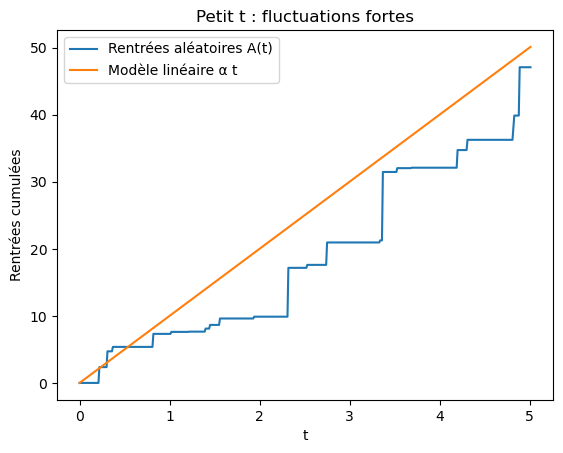

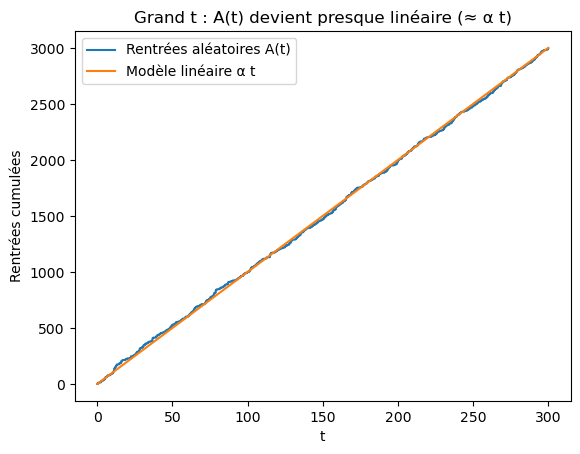

In [ ]:
## Modelisation $\alpha$t
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Paramètres
# -------------------------
lam = 5.0          # clients par unité de temps
depense_moy = 2.0  # dépense moyenne par client
alpha = lam * depense_moy  # pente moyenne (≈ rentrées moyennes par unité de temps)
dt = 0.01

# -------------------------
# Simulation sur un temps T
# (on fait une trajectoire)
# -------------------------
def faire_simulation(T, graine):
    np.random.seed(graine)

    t = 0.0        # temps courant
    A = 0.0        # rentrées cumulées

    liste_t = [t]  # pour tracer
    liste_A = [A]

    while t < T:
        # nombre de clients pendant le petit intervalle dt
        n = np.random.poisson(lam * dt)

        # somme des dépenses des n clients
        depenses = 0.0
        for i in range(n):
            depenses = depenses + np.random.exponential(depense_moy)

        # mise à jour des rentrées
        A = A + depenses

        # avancer le temps
        t = t + dt

        # stocker pour le graphique
        liste_t.append(t)
        liste_A.append(A)

    return liste_t, liste_A

# -------------------------
# 1) Petit temps
# -------------------------
t_petit = 5
temps1, A1 = faire_simulation(t_petit, graine=1)

plt.figure()
plt.plot(temps1, A1, label="Rentrées aléatoires A(t)")
plt.plot(temps1, alpha * np.array(temps1), label="Modèle linéaire α t")
plt.title("Petit t : fluctuations fortes")
plt.xlabel("t")
plt.ylabel("Rentrées cumulées")
plt.legend()
plt.show()

# -------------------------
# 2) Grand temps
# -------------------------
t_grand = 300
temps2, A2 = faire_simulation(t_grand, graine=2)

plt.figure()
plt.plot(temps2, A2, label="Rentrées aléatoires A(t)")
plt.plot(temps2, alpha * np.array(temps2), label="Modèle linéaire α t")
plt.title("Grand t : A(t) devient presque linéaire (≈ α t)")
plt.xlabel("t")
plt.ylabel("Rentrées cumulées")
plt.legend()
plt.show()
